# Setup and Imports


In [53]:
import os
print(os.path.abspath('../src'))
print(os.listdir(os.path.abspath('../src')))

c:\Users\shree\Desktop\transceiver-project\src
['awgn.py', 'awgn_snr.py', 'data_utils.py', 'demodulator.py', 'hamming.py', 'modulator.py', 'plot_utils.py', 'sync.py', 'testing', '__init__.py', '__pycache__']


In [54]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    estimate_baseband_bandwidth,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    slice_pilot_samples,
    downsample_from_offset,
    symbols_to_bits
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response, plot_fft
from sync import generate_zadoff_chu_audio
import awgn_snr
import config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [55]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = config.SYNC_GAP_SECONDS

rx_path = '../data/tx_single_carrier_test.wav'



""" rx_path = '../data/tx_single_carrier_test.wav' """

" rx_path = '../data/tx_single_carrier_test.wav' "

# Load and Downconvert Audio


In [56]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')

rx_audio_awgn = awgn_snr.add_awgn_snr(rx_audio,10)

rx_baseband = downconvert_to_baseband(
    rx_audio = rx_audio_awgn,
    fs=FS,
    carrier_freq=F_CARRIER,
    cutoff_hz= 3500,
    filter_order=5
)
#njfsbdjfbsdjf

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

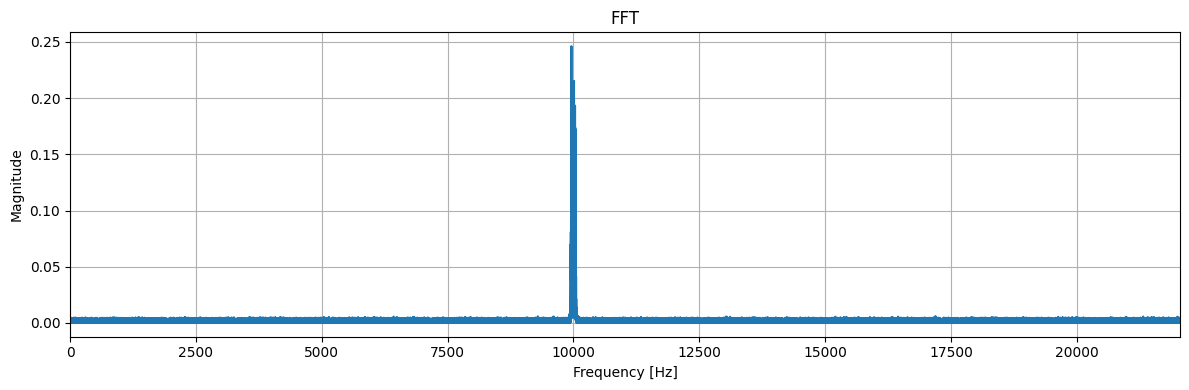

In [57]:
plot_fft(rx_audio_awgn,fs)

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'FFT'}, xlabel='Frequency [Hz]', ylabel='Magnitude'>)

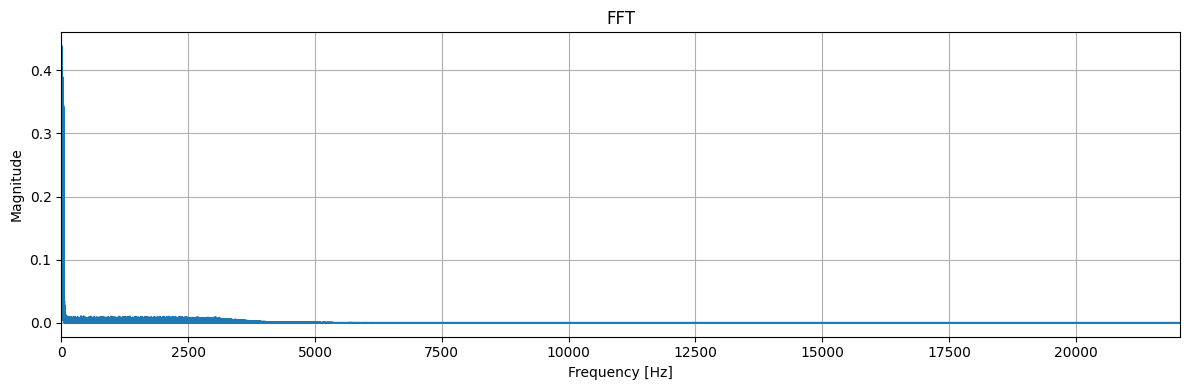

In [58]:
plot_fft(rx_baseband,fs)

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

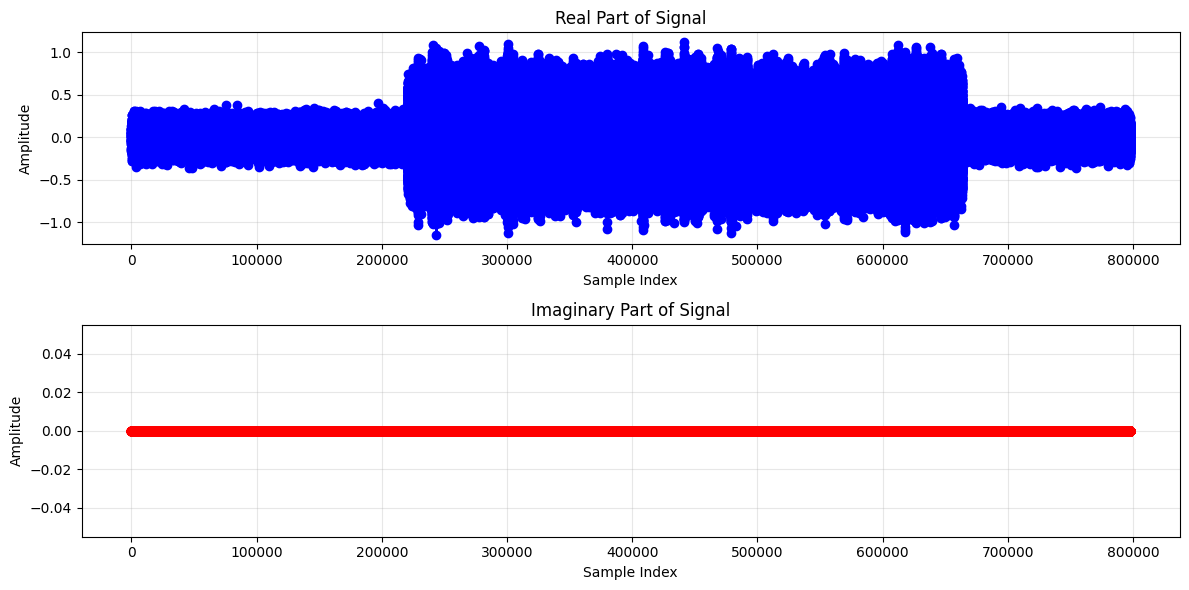

In [59]:
plot_complex_parts(rx_audio_awgn)

In [60]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)

pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 220500
Known pilots begin at sample index: 220853
--------------------------------------------------


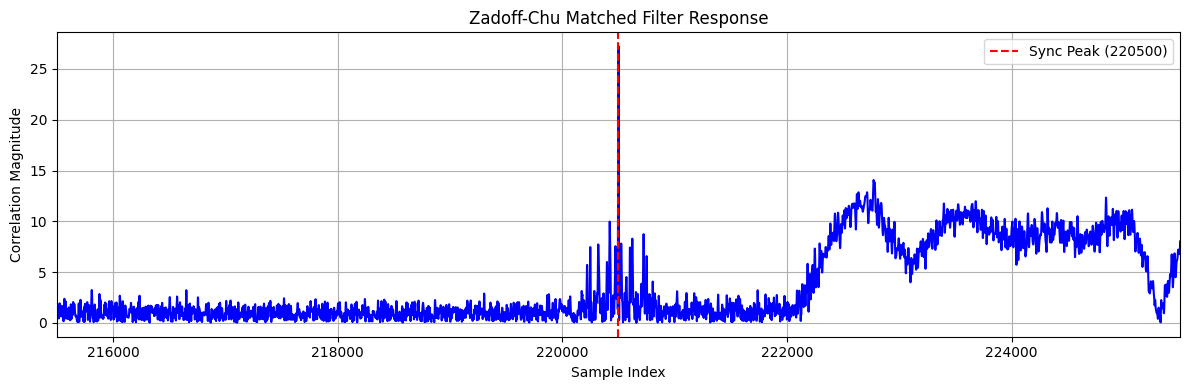

In [61]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [62]:
pilot_bits = config.pilot_bits
pilot_symbols = map_bits_to_symbols(pilot_bits, config.M, METHOD=config.modulation_method)
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

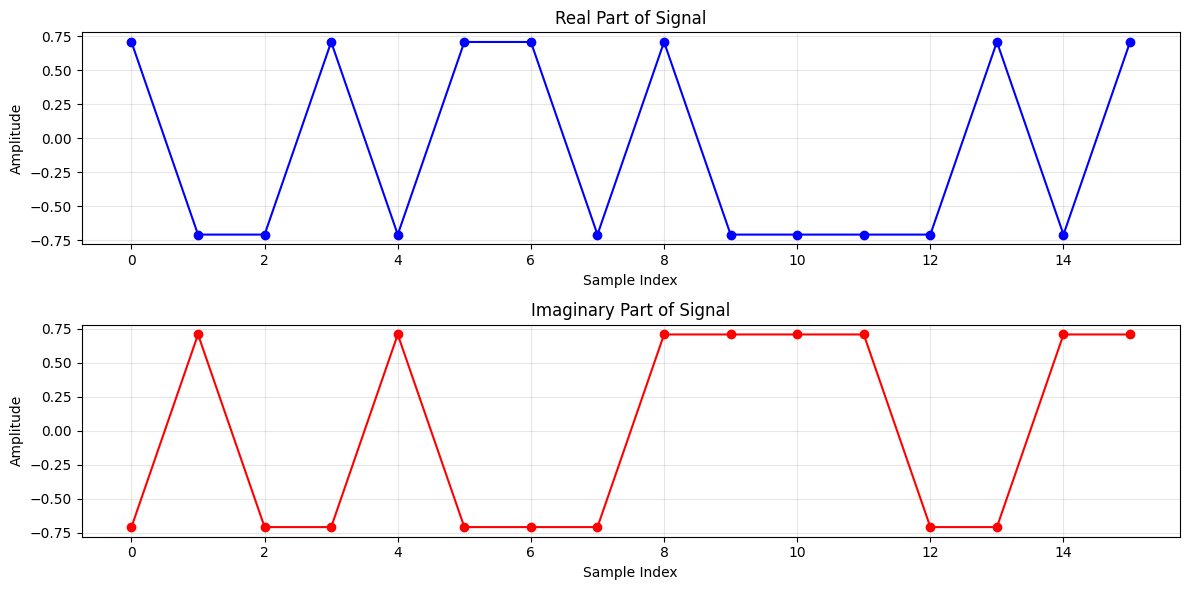

In [63]:
plot_complex_parts(pilot_symbols)

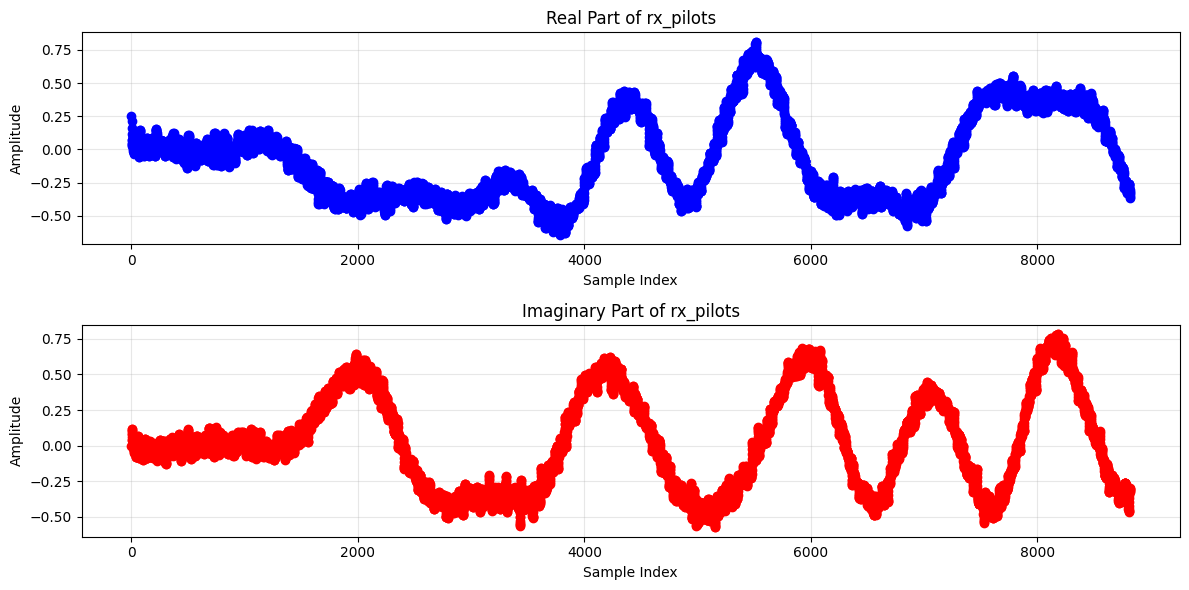

In [64]:
plot_complex_parts(rx_pilots, title_prefix='rx_pilots')
plt.show()

### Synchronization 

Best offset inside pilot slice: 132


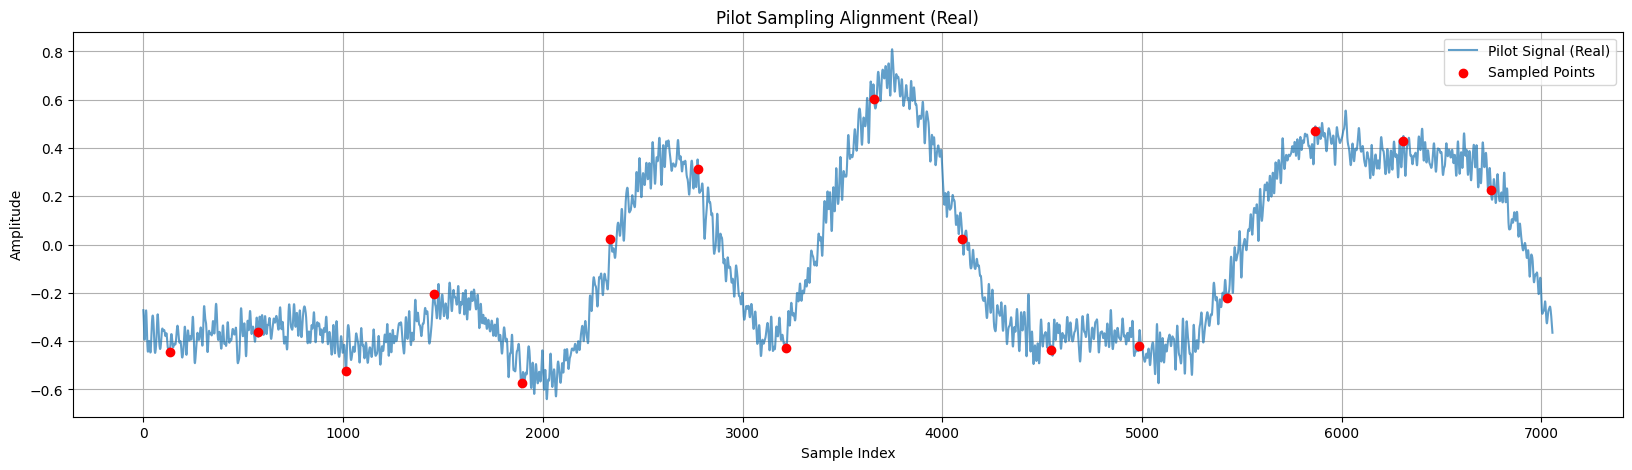

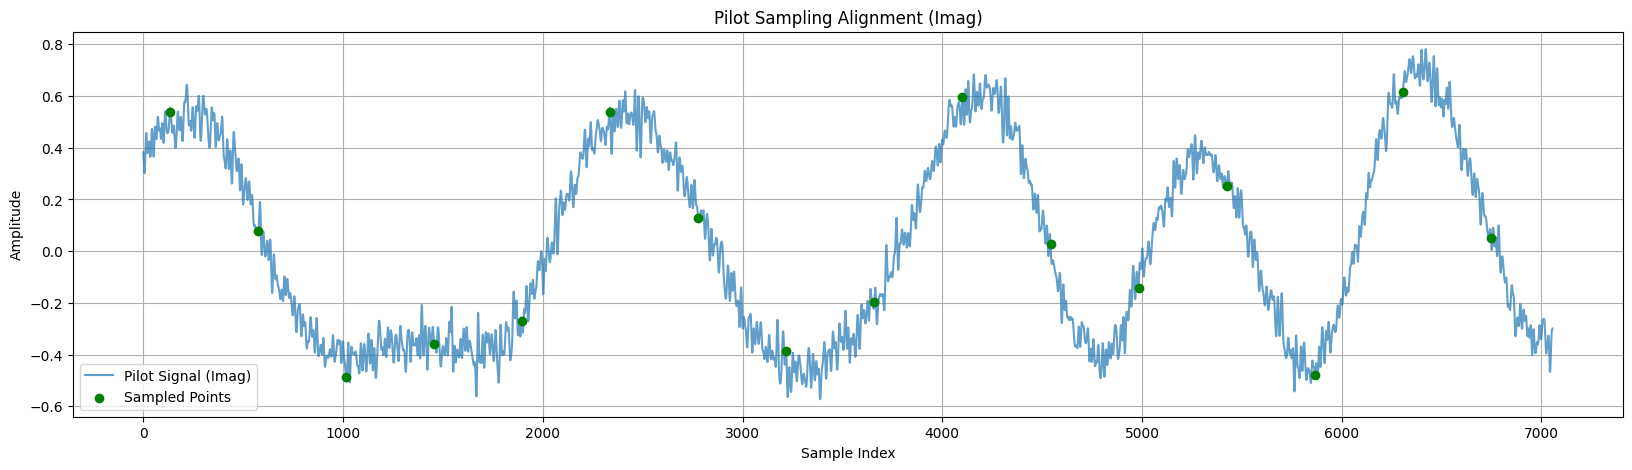


Known pilot symbols:
[ 0.70710678-0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678+0.70710678j  0.70710678-0.70710678j
  0.70710678-0.70710678j -0.70710678-0.70710678j  0.70710678+0.70710678j
 -0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678+0.70710678j
 -0.70710678-0.70710678j  0.70710678-0.70710678j -0.70710678+0.70710678j
  0.70710678+0.70710678j]

Recovered pilot samples:
[-0.4429005 +0.53875264j -0.36357974+0.07647565j -0.52307571-0.48495833j
 -0.20321846-0.35852653j -0.57236104-0.26850939j  0.02427881+0.53892876j
  0.31195988+0.12852331j -0.43003116-0.38595269j  0.60192707-0.19724806j
  0.02211924+0.59590889j -0.43621099+0.02598622j -0.41839337-0.14361456j
 -0.22163439+0.25017919j  0.47187089-0.4806567j   0.43058349+0.61537895j
  0.22822663+0.05092599j]


In [65]:
L = SAMPLES_PER_SYMBOL
KNOWN = KNOWN_PILOT_SYMBOLS

# ================================
# REMOVE SINC DELAY REGION
# ================================
rxp = rx_pilots[config.SPAN * L:]

NUM_PILOTS = len(KNOWN)

# ================================
# FIND BEST OFFSET
# ================================
best_offset = 0
best_metric = -np.inf

for offset in range(L):
    samples = rxp[offset::L][:NUM_PILOTS]
    
    metric = np.abs(np.sum(samples * np.conj(KNOWN)))
    
    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print(f"Best offset inside pilot slice: {best_offset}")

# ================================
# GET FINAL SAMPLE INDICES
# ================================
sample_indices = np.arange(best_offset, best_offset + NUM_PILOTS*L, L)

# ================================
# PLOT REAL PART
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(20,5))

plt.plot(np.real(rxp), label="Pilot Signal (Real)", alpha=0.7)

plt.scatter(sample_indices,
            np.real(rxp[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Real)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# PLOT IMAG PART
# ================================
plt.figure(figsize=(20,5))

plt.plot(np.imag(rxp), label="Pilot Signal (Imag)", alpha=0.7)

plt.scatter(sample_indices,
            np.imag(rxp[sample_indices]),
            color='green',
            label="Sampled Points",
            zorder=5)

plt.title("Pilot Sampling Alignment (Imag)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

# ================================
# VERIFY SYMBOLS
# ================================
rx_samples = rxp[best_offset::L][:NUM_PILOTS]

print("\nKnown pilot symbols:")
print(KNOWN)

print("\nRecovered pilot samples:")
print(rx_samples)

In [66]:
start = pilot_start_idx + config.SPAN * L + best_offset

downsampled_symbols, ds_signal = downsample_from_offset(
    rx_baseband,
    start,
    L
)

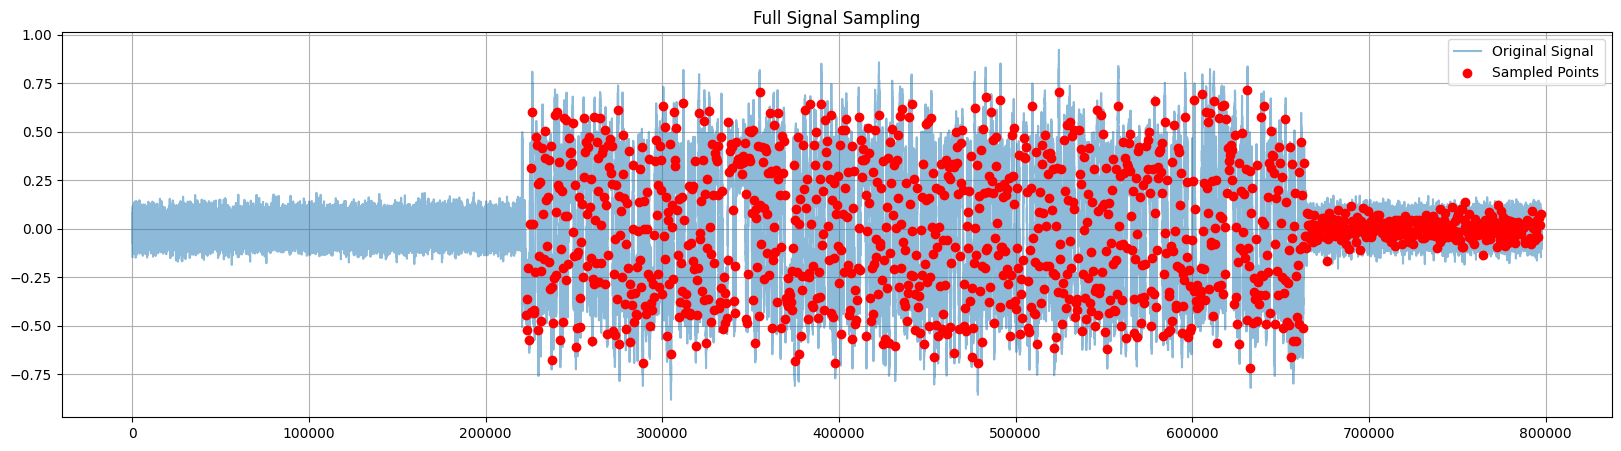

In [67]:
plt.figure(figsize=(20,5))

plt.plot(np.real(rx_baseband), label="Original Signal", alpha=0.5)

sample_indices = np.arange(start, len(rx_baseband), L)

plt.scatter(sample_indices,
            np.real(rx_baseband[sample_indices]),
            color='red',
            label="Sampled Points",
            zorder=5)

plt.title("Full Signal Sampling")
plt.grid(True)
plt.legend()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Real Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>,
        <Axes: title={'center': 'Imaginary Part of Signal'}, xlabel='Sample Index', ylabel='Amplitude'>],
       dtype=object))

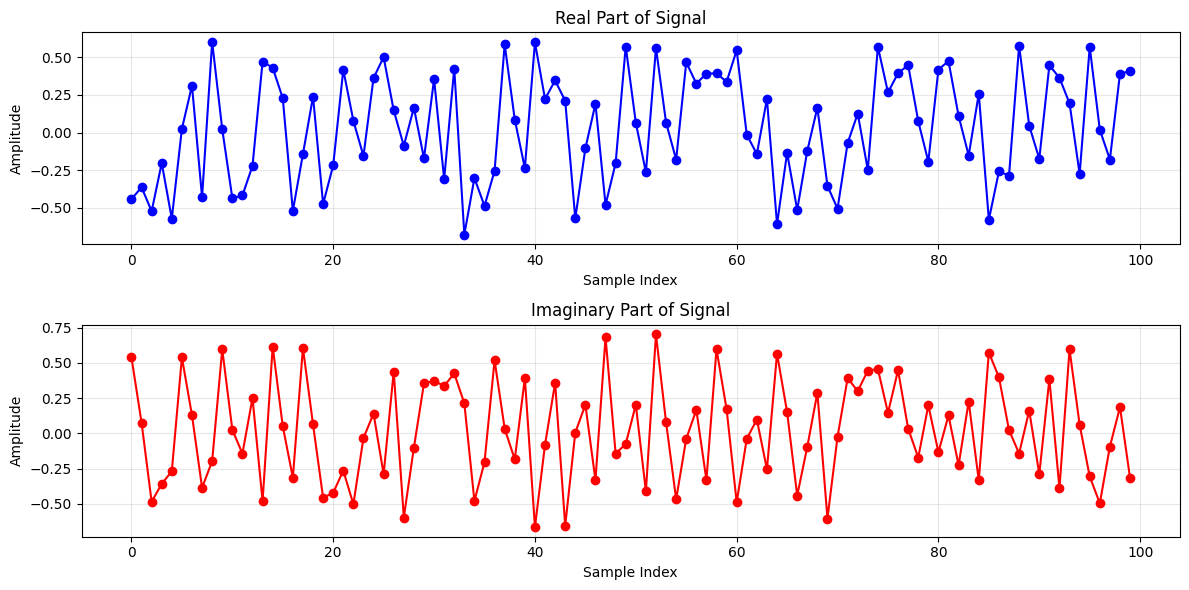

In [68]:
plot_complex_parts(rx_baseband[sample_indices][0:100])

In [69]:
recovered_bits = symbols_to_bits(
    downsampled_symbols,
    M=config.M,
    METHOD=config.modulation_method
)

In [70]:
input_path = "../data/message.txt"
with open(input_path, "r") as f:
        data_binary = f.read().strip()


# Calculate Bit Error Rate (BER)
recovered_bit_string = ''.join(map(str, recovered_bits))

# Determine the length to compare (use the shorter length or match as needed)
min_length = min(len(recovered_bit_string), len(data_binary))

# Compare bits
bit_errors = sum(r != d for r, d in zip(recovered_bit_string[:min_length], data_binary[:min_length]))

# Calculate BER
ber = bit_errors / min_length if min_length > 0 else 0

print(f"Recovered bits: {recovered_bit_string[:min_length]}")
print(f"Original bits:  {data_binary[:min_length]}")
print(f"\nTotal bits compared: {min_length}")
print(f"Bit errors: {bit_errors}")
print(f"Bit Error Rate (BER): {ber:.6f} ({ber*100:.2f}%)")

Recovered bits: 010100000011110010110100011011110001110000101000111011001001110111010000011110011010111001011001001011001111001011101111100001100101000011000001110111111111100110111001100101011011001110110110100011101101101001001010101110100100010111011110000011001111100001001100100101000100110001000001011101100110000010000100110011010101010000001110110011011011110011000011100010100110001110011111101011011000000011011111010101010010010001110010011100010000110001100111001011000011011111000011110101111110101001010110100000010101010011101111111110010000101010111111111011111110110000001011101010011111001010001101101000111010001010110111001010110101111100100110111111010111111111010001010101000101000110011110001001101100000011101011001101000010100001001010101001010010011001001000111110101000100010100001100010100111001001011110011111111001110000011001111001000001001011011010111011101101011010100101011001011100011101110000110110000100101101110000111110100010011010111000111001100101000111010000

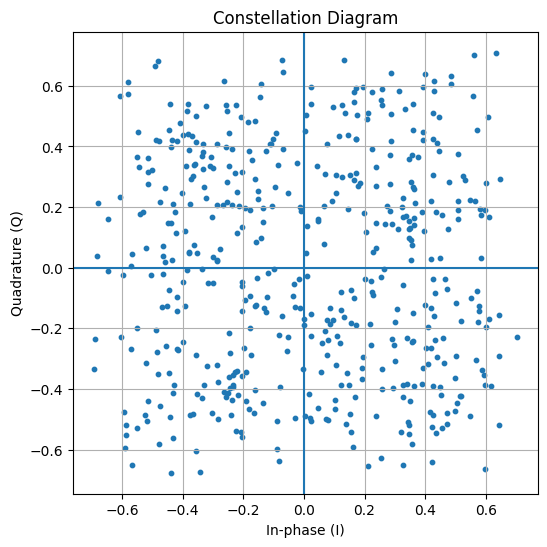

In [71]:
plt.figure(figsize=(6,6))

no_of_symbols_to_plot = 500
downsampled_symbols = downsampled_symbols[: no_of_symbols_to_plot]

plt.scatter(np.real(downsampled_symbols),
            np.imag(downsampled_symbols),
            s=10)

plt.axhline(0)
plt.axvline(0)

plt.title("Constellation Diagram")
plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")
plt.grid(True)
plt.axis('equal')

plt.show()